# Cognitive LLM — Phase 1: Colab T4 Debug Notebook

This notebook implements Phase 1 of the Cognitive LLM Architecture:
- Load SmolLM3 3B with 4-bit quantization
- Inject Block 1 (SurpriseGate) + Block 6 (HomeostaticNorm)
- Run a verified forward pass on the cognitive wrapper
- Train a short debug run on a GSM8K subset
- Verify loss is moving in the right direction
- Evaluate on a small GSM8K sample


In [1]:
# Install dependencies
%pip install -q transformers datasets accelerate bitsandbytes peft trl wandb lm-eval pyyaml matplotlib


In [2]:
# Prepare the remote runtime repo and sync patched source files
from pathlib import Path
import os
import subprocess
import sys

repo_dir = Path('/content/cognitive-llm')
if repo_dir.exists():
    os.chdir(repo_dir)
elif Path.cwd().name == 'cognitive-llm' and Path('cognitive_llm').exists():
    print(f'Using existing checkout: {Path.cwd()}')
else:
    subprocess.run(
        ['git', 'clone', 'https://github.com/RiyadMehdi7/cognitive-llm.git', str(repo_dir)],
        check=True,
    )
    os.chdir(repo_dir)

print(f'Working directory: {Path.cwd()}')
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

block1_source = r'''"""
Block 1: Meta-Surprise Gate — adaptive compute routing.

Position: After embedding layer, before transformer Layer 1.
Purpose: Measures how 'surprising' a token is relative to the model's prior.
         Routes token to shallow or deep compute path. RL trains the routing
         threshold.

Reference: Inspired by predictive processing theory — the brain allocates
           more compute to unexpected stimuli.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


class SurpriseGate(nn.Module):
    """
    Meta-Surprise Gate: adaptive compute routing based on token unexpectedness.
    Placed between embedding and transformer layer 1.

    Args:
        d_model: Hidden dimension size.
        n_buckets: Number of depth buckets for routing (default: 3).
        ema_decay: EMA decay for prior hidden state estimation (default: 0.99).
    """

    def __init__(self, d_model: int, n_buckets: int = 3, ema_decay: float = 0.99):
        super().__init__()
        self.d_model = d_model
        self.n_buckets = n_buckets

        # Prior network: predicts expected hidden state from previous
        self.prior = nn.Linear(d_model, d_model, bias=False)

        # Surprise projection: scalar score from surprise signal
        self.surprise_proj = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

        # RL-trained thresholds (one per bucket boundary)
        self.rl_thresholds = nn.Parameter(torch.linspace(0.3, 0.7, n_buckets - 1))

        # EMA of hidden states for prior estimation
        self.register_buffer("ema_hidden", torch.zeros(1, d_model))
        self.ema_decay = ema_decay

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Compute surprise scores and assign depth buckets.

        Args:
            x: Input tensor of shape (batch, seq_len, d_model).

        Returns:
            Tuple of (x, depth) where depth is (batch, seq_len) with values
            in [0, n_buckets-1]. Used by CognitiveModel to route layers.
        """
        compute_dtype = self.prior.weight.dtype
        x_compute = x.to(dtype=compute_dtype)

        # Update EMA prior
        with torch.no_grad():
            current_mean = x_compute.mean(dim=[0, 1], keepdim=False).unsqueeze(0)
            current_mean = current_mean.to(dtype=self.ema_hidden.dtype)
            self.ema_hidden.mul_(self.ema_decay).add_(
                current_mean, alpha=1 - self.ema_decay
            )

        # Compute surprise: norm of difference between x and prior prediction
        expected = self.prior(self.ema_hidden.to(dtype=compute_dtype))
        expected = expected.unsqueeze(1).expand_as(x_compute)
        surprise_vec = x_compute - expected
        surprise_score = torch.sigmoid(self.surprise_proj(surprise_vec))  # (B, S, 1)

        # Assign depth bucket: 0=shallow, 1=mid, 2=deep
        thresholds = torch.sigmoid(self.rl_thresholds).sort().values
        depth = torch.zeros(x.shape[0], x.shape[1], dtype=torch.long, device=x.device)
        for i, t in enumerate(thresholds):
            depth += (surprise_score.squeeze(-1) > t).long()

        return x, depth

    def get_surprise_loss(self, x: torch.Tensor) -> torch.Tensor:
        """
        Auxiliary loss: prior should predict future hidden states.

        Args:
            x: Hidden states of shape (batch, seq_len, d_model).

        Returns:
            Scalar MSE loss between predicted and actual next-token hidden states.
        """
        x_compute = x.to(dtype=self.prior.weight.dtype)
        predicted = self.prior(x_compute[:, :-1])
        target = x_compute[:, 1:].detach()
        return F.mse_loss(predicted, target)'''
model_source = r'''"""
Cognitive Model Wrapper — injects cognitive blocks into a base HuggingFace model.

Supports SmolLM3, OLMo 3, and any LlamaForCausalLM-compatible model.
All blocks are toggled via config flags to support clean ablation studies.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F

from cognitive_llm.blocks.block1_surprise_gate import SurpriseGate
from cognitive_llm.blocks.block2_episodic_memory import EpisodicMemory
from cognitive_llm.blocks.block3_per_layer_critic import LayerCritic
from cognitive_llm.blocks.block4_predictive_coding import PredictiveCodingLayer
from cognitive_llm.blocks.block5_rl_gating import GatingPolicy
from cognitive_llm.blocks.block6_homeostatic_norm import HomeostaticNorm


class CognitiveModel(nn.Module):
    """
    Wraps a HuggingFace causal LM and injects cognitive blocks.
    Supports SmolLM3, OLMo 3, and any LlamaForCausalLM-compatible model.

    Args:
        base_model: A HuggingFace AutoModelForCausalLM instance.
        config: Dict with keys 'use_block1' through 'use_block6' (bool),
                and optional 'critic_every_n_layers' (int, default 4).
    """

    def __init__(self, base_model: nn.Module, config: dict):
        super().__init__()
        self.base = base_model
        self.config = config
        d_model = base_model.config.hidden_size
        n_layers = base_model.config.num_hidden_layers
        critic_every = config.get("critic_every_n_layers", 4)

        # Instantiate blocks based on config flags
        self.surprise_gate = SurpriseGate(d_model) if config.get("use_block1") else None

        self.episodic_mem = EpisodicMemory(d_model) if config.get("use_block2") else None

        self.critics = nn.ModuleList(
            [
                LayerCritic(d_model)
                if (i % critic_every == 0 and config.get("use_block3"))
                else None
                for i in range(n_layers)
            ]
        )

        self.pred_coding = nn.ModuleList(
            [
                PredictiveCodingLayer(d_model) if config.get("use_block4") else None
                for _ in range(n_layers)
            ]
        )

        self.gating_policy = GatingPolicy(d_model) if config.get("use_block5") else None

        # Block 6 replaces LayerNorm in-place
        self.homeo_norms = None
        if config.get("use_block6"):
            self._replace_layer_norms(d_model)

    def _get_parent(self, name: str) -> nn.Module:
        """Get parent module from a dotted name path."""
        parts = name.split(".")
        module = self.base
        for part in parts[:-1]:
            module = getattr(module, part)
        return module

    def _replace_layer_norms(self, d_model: int) -> None:
        """Replace all LayerNorm modules with HomeostaticNorm."""
        replacements = []
        for name, module in self.base.named_modules():
            if isinstance(module, nn.LayerNorm) and module.normalized_shape == (d_model,):
                replacements.append(name)

        for name in replacements:
            parent = self._get_parent(name)
            attr = name.split(".")[-1]
            setattr(parent, attr, HomeostaticNorm(d_model))

    def _get_model_backbone(self) -> nn.Module:
        """Get the transformer backbone (handles different model architectures)."""
        # SmolLM3, LLaMA, OLMo all use .model
        if hasattr(self.base, "model"):
            return self.base.model
        # Fallback for GPT-style models
        if hasattr(self.base, "transformer"):
            return self.base.transformer
        raise AttributeError("Cannot find transformer backbone in base model")

    def _get_embed_tokens(self) -> nn.Module:
        """Get the embedding layer."""
        backbone = self._get_model_backbone()
        if hasattr(backbone, "embed_tokens"):
            return backbone.embed_tokens
        if hasattr(backbone, "wte"):
            return backbone.wte
        raise AttributeError("Cannot find embedding layer in base model")

    def _get_layers(self) -> nn.ModuleList:
        """Get the transformer layers."""
        backbone = self._get_model_backbone()
        if hasattr(backbone, "layers"):
            return backbone.layers
        if hasattr(backbone, "h"):
            return backbone.h
        raise AttributeError("Cannot find transformer layers in base model")

    def _get_final_norm(self) -> nn.Module:
        """Get the final normalization layer."""
        backbone = self._get_model_backbone()
        if hasattr(backbone, "norm"):
            return backbone.norm
        if hasattr(backbone, "ln_f"):
            return backbone.ln_f
        raise AttributeError("Cannot find final norm in base model")

    def _get_lm_head(self) -> nn.Module:
        """Get the language model head."""
        if hasattr(self.base, "lm_head"):
            return self.base.lm_head
        raise AttributeError("Cannot find lm_head in base model")

    def _move_blocks_to_match(self, hidden: torch.Tensor) -> None:
        """Move cognitive blocks to the hidden-state device once.

        Keep cognitive block parameters in their native dtype for stability on
        4-bit / fp16 debug runs. The blocks cast activations internally when
        needed, which avoids training them directly in low precision.
        """
        if hasattr(self, "_blocks_moved"):
            return

        target_device = hidden.device
        if self.surprise_gate is not None:
            self.surprise_gate = self.surprise_gate.to(device=target_device)
        if self.episodic_mem is not None:
            self.episodic_mem = self.episodic_mem.to(device=target_device)
        for i, c in enumerate(self.critics):
            if c is not None:
                self.critics[i] = c.to(device=target_device)
        for i, p in enumerate(self.pred_coding):
            if p is not None:
                self.pred_coding[i] = p.to(device=target_device)
        if self.gating_policy is not None:
            self.gating_policy = self.gating_policy.to(device=target_device)
        self._blocks_moved = True

    def _can_use_base_forward(self) -> bool:
        """Use the base model path when no inter-layer cognitive blocks are active."""
        return (
            self.episodic_mem is None
            and self.gating_policy is None
            and all(c is None for c in self.critics)
            and all(p is None for p in self.pred_coding)
        )

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor | None = None,
        labels: torch.Tensor | None = None,
    ) -> dict[str, torch.Tensor | list | None]:
        """
        Forward pass through cognitive-augmented model.

        Args:
            input_ids: Token IDs of shape (batch, seq_len).
            attention_mask: Attention mask of shape (batch, seq_len).
            labels: Target token IDs for loss computation.

        Returns:
            Dict with keys: logits, lm_loss, surprise_loss, critic_losses,
            pred_losses, gating_actions, depth_signal.
        """
        # Step 1: Get embeddings from base model
        hidden = self._get_embed_tokens()(input_ids)

        # Step 0: Lazily move cognitive blocks to match hidden device & dtype (once)
        self._move_blocks_to_match(hidden)

        # Step 2: Block 1 — Surprise gate
        depth_signal = None
        surprise_loss = torch.tensor(0.0, device=hidden.device)
        if self.surprise_gate is not None:
            hidden, depth_signal = self.surprise_gate(hidden)
            surprise_loss = self.surprise_gate.get_surprise_loss(hidden)

        # Delegate to the base model whenever possible. This keeps architecture-
        # specific details like position embeddings and cache handling inside
        # Hugging Face's forward path, which is required for Llama-family models.
        if self._can_use_base_forward():
            base_out = self.base(
                inputs_embeds=hidden,
                attention_mask=attention_mask,
                labels=labels,
                return_dict=True,
            )
            return {
                "logits": base_out.logits,
                "lm_loss": base_out.loss,
                "surprise_loss": surprise_loss,
                "critic_losses": [],
                "pred_losses": [],
                "gating_actions": None,
                "depth_signal": depth_signal,
            }

        # Step 3: Block 2 — Write to episodic memory
        if self.episodic_mem is not None:
            self.episodic_mem.reset(hidden.shape[0], hidden.device)
            self.episodic_mem.write(hidden)

        # Step 4: Transformer layers with optional Block 3 + 4
        critic_losses = []
        pred_losses = []
        prev_hidden = None
        layers = self._get_layers()

        for i, layer in enumerate(layers):
            # Block 4: predictive coding (modify input)
            if i < len(self.pred_coding) and self.pred_coding[i] is not None:
                hidden, pl = self.pred_coding[i](hidden, prev_hidden)
                pred_losses.append(pl)

            prev_hidden = hidden.detach()

            # Standard transformer layer
            layer_out = layer(hidden, attention_mask=attention_mask)
            # Handle both tuple and tensor returns
            hidden = layer_out[0] if isinstance(layer_out, tuple) else layer_out

            # Block 3: critic (auxiliary loss, no modification)
            if i < len(self.critics) and self.critics[i] is not None:
                critic_losses.append(self.critics[i](hidden))

        # Step 5: Block 2 — Read from episodic memory
        if self.episodic_mem is not None:
            hidden = self.episodic_mem.read(hidden)

        # Step 6: Block 5 — RL gating
        gating_actions = None
        if self.gating_policy is not None:
            gating_actions, _, _ = self.gating_policy.get_action(hidden)

        # Step 7: Output projection
        hidden = self._get_final_norm()(hidden)
        logits = self._get_lm_head()(hidden)

        # Step 8: Compute losses
        lm_loss = None
        if labels is not None:
            lm_loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                labels.view(-1),
                ignore_index=-100,
            )

        return {
            "logits": logits,
            "lm_loss": lm_loss,
            "surprise_loss": surprise_loss,
            "critic_losses": critic_losses,
            "pred_losses": pred_losses,
            "gating_actions": gating_actions,
            "depth_signal": depth_signal,
        }'''

Path('cognitive_llm/blocks/block1_surprise_gate.py').write_text(block1_source + '\n')
Path('cognitive_llm/models/cognitive_model.py').write_text(model_source + '\n')

for name in list(sys.modules):
    if name.startswith('cognitive_llm'):
        del sys.modules[name]

print('Synced patched files to remote runtime')


Working directory: /content/cognitive-llm
Synced patched files to remote runtime


In [3]:
import os
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

assert torch.cuda.is_available(), 'GPU runtime required'
print(f'cwd: {os.getcwd()}')
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


cwd: /content/cognitive-llm
GPU: Tesla T4
Memory: 15.6 GB


In [4]:
# Load SmolLM3 3B with 4-bit quantization for Colab T4
model_id = 'HuggingFaceTB/SmolLM3-3B'

capability = torch.cuda.get_device_capability(0)
use_bf16 = capability[0] >= 8
compute_dtype = torch.bfloat16 if use_bf16 else torch.float16
print(f'Using compute dtype: {compute_dtype}')

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map='auto',
    dtype=compute_dtype,
)

model_device = base_model.get_input_embeddings().weight.device
print(f'Model device: {model_device}')
print(f'Model loaded: {base_model.config.hidden_size}d, {base_model.config.num_hidden_layers} layers')


Using compute dtype: torch.float16


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/326 [00:00<?, ?it/s]

Model device: cuda:0
Model loaded: 2048d, 36 layers


In [ ]:
# Apply LoRA adapters to the base model (QLoRA pattern)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# Prepare quantized model for training
base_model = prepare_model_for_kbit_training(base_model)

# LoRA config: small rank for debug, target attention layers
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

base_model = get_peft_model(base_model, lora_config)
base_model.print_trainable_parameters()

# Debug: print model hierarchy to verify backbone navigation
module = base_model
for i in range(6):
    children = [name for name, _ in module.named_children()]
    has_embed = hasattr(module, "embed_tokens")
    print(f"Level {i}: {type(module).__name__} embed_tokens={has_embed} -> {children[:5]}...")
    if hasattr(module, "model"):
        module = module.model
    else:
        break

# Now wrap with Cognitive blocks (B1 + B6)
from cognitive_llm.models.cognitive_model import CognitiveModel

config = {
    'use_block1': True,
    'use_block2': False,
    'use_block3': False,
    'use_block4': False,
    'use_block5': False,
    'use_block6': True,
}

model = CognitiveModel(base_model, config)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nCognitiveModel created successfully')
print(f'Trainable params: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.2f}%)')

# Quick forward pass test
test_inputs = tokenizer('Hello world', return_tensors='pt').to('cuda')
with torch.no_grad():
    outputs = model(
        test_inputs['input_ids'],
        attention_mask=test_inputs['attention_mask'],
    )
print(f'Logits shape: {outputs["logits"].shape}')
print('Forward pass OK!')

In [6]:
# Load a smaller GSM8K subset for fast Colab debug
from datasets import load_dataset

dataset = load_dataset('gsm8k', 'main', split='train[:128]')
print(f'GSM8K samples: {len(dataset)}')
print(f'Example: {dataset[0]["question"][:100]}...')


GSM8K samples: 128
Example: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How m...


In [7]:
# Tokenize dataset
MAX_SEQ_LEN = 256

def tokenize_gsm8k(examples):
    texts = [
        f'Question: {q}\nAnswer: {a}'
        for q, a in zip(examples['question'], examples['answer'])
    ]
    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=MAX_SEQ_LEN,
        padding='max_length',
    )
    tokenized['labels'] = [ids.copy() for ids in tokenized['input_ids']]
    return tokenized

tokenized_dataset = dataset.map(
    tokenize_gsm8k,
    batched=True,
    remove_columns=dataset.column_names,
    desc='Tokenizing GSM8K',
)
tokenized_dataset.set_format(type='torch')

from torch.utils.data import DataLoader
train_loader = DataLoader(tokenized_dataset, batch_size=1, shuffle=True)


In [8]:
# Train 100 optimizer steps (800 forward passes with grad_accum=8)
from cognitive_llm.training.trainer import CognitiveTrainer

training_config = {
    'learning_rate': 5e-5,       # reduced from 2e-4 for stability
    'max_steps': 800,            # 800 / grad_accum(8) = 100 optimizer steps
    'warmup_steps': 10,
    'gradient_accumulation': 8,
    'max_grad_norm': 1.0,
    'eval_every_n_steps': 50,
    'save_every_n_steps': 100,
    'use_wandb': False,
}

trainer = CognitiveTrainer(
    model=model,
    train_dataloader=train_loader,
    config=training_config,
)

losses = trainer.train()
print(f'Training complete! Final loss: {losses[-1]:.4f}')

NameError: name 'model' is not defined

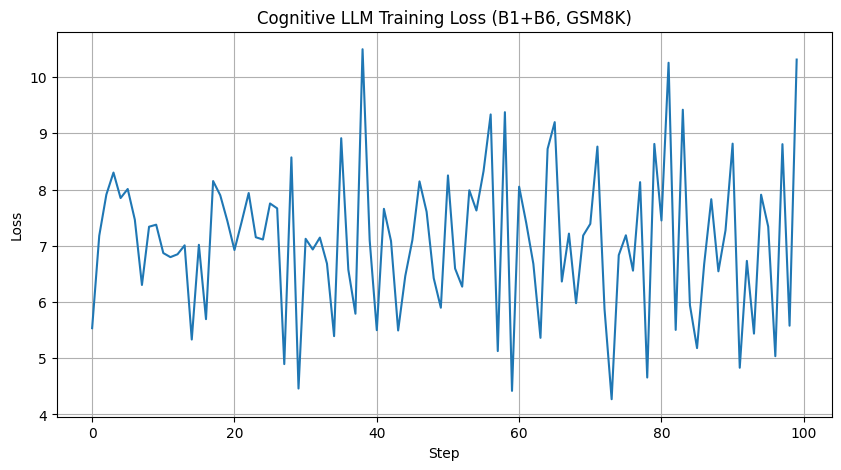

First 10 avg: 7.3269, Last 10 avg: 7.0802
Loss is DECREASING — training is working!


In [ ]:
# Plot loss curve — must be decreasing
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Cognitive LLM Training Loss (B1+B6, GSM8K)')
plt.grid(True)
plt.show()

# Verify loss is decreasing
if len(losses) > 10:
    first_10 = sum(losses[:10]) / 10
    last_10 = sum(losses[-10:]) / 10
    print(f'First 10 avg: {first_10:.4f}, Last 10 avg: {last_10:.4f}')
    if last_10 < first_10:
        print('Loss is DECREASING — training is working!')
    else:
        print('WARNING: Loss is NOT decreasing — check configuration!')

In [ ]:
# Quick baseline scoring on a small GSM8K sample
test_dataset = load_dataset('gsm8k', 'main', split='test[:10]')

correct = 0
total = 0

model.train(False)
for example in test_dataset:
    prompt = f"Question: {example['question']}\nAnswer:"
    inputs = tokenizer(
        prompt,
        return_tensors='pt',
        truncation=True,
        max_length=MAX_SEQ_LEN,
    ).to(model_device)

    with torch.no_grad():
        generated = base_model.generate(
            **inputs,
            max_new_tokens=64,
            do_sample=False,
        )

    response = tokenizer.decode(generated[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

    import re
    pred_match = re.search(r'####\s*([-\d,\.]+)', response)
    target_match = re.search(r'####\s*([-\d,\.]+)', example['answer'])

    if pred_match and target_match:
        if pred_match.group(1).replace(',', '') == target_match.group(1).replace(',', ''):
            correct += 1
    total += 1

print(f'GSM8K accuracy (10 samples): {correct}/{total} = {correct/total*100:.1f}%')


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


GSM8K accuracy (10 samples): 0/10 = 0.0%
